In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Formatter to show readable dollar amounts instead of scientific notation
money_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

print('Ready!')

Ready!


In [2]:
df = pd.read_excel('finance_transactions_dataset.xlsx')

# Check rows and columns
print(df.shape) 
print(df.columns.tolist())

(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [3]:
# Cell 3a: Preview first rows
df.head()

# Cell 3b: Check column types and missing counts
df.info()

# Cell 3c: Summary statistics
df.describe().round(2)

# Cell 3d: Count missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


Transaction_ID        0
Company              44
Sector                0
Department           54
Transaction_Type      0
Category            789
Amount               39
Tax_Rate              0
Tax_Amount            0
Net_Amount           40
Currency              0
Transaction_Date     48
Approval_Status      39
Analyst              45
dtype: int64

In [4]:
# Cell 4a: Remove rows with missing critical values
df.dropna(subset=['Amount', 'Net_Amount', 'Transaction_Date', 'Approval_Status'], inplace=True)

# Cell 4b: Fill gaps in text columns
df['Company'] = df['Company'].fillna('Unknown')
df['Department'] = df['Department'].fillna('Unknown')
df['Analyst'] = df['Analyst'].fillna('Unknown')
df['Category'] = df['Category'].fillna('N/A')

# Cell 4c: Convert text dates to proper date format
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df.dropna(subset=['Transaction_Date'], inplace=True)
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)

# Cell 4d: Remove duplicates
df.drop_duplicates(inplace=True)
print('Final row count:', len(df))

Final row count: 845


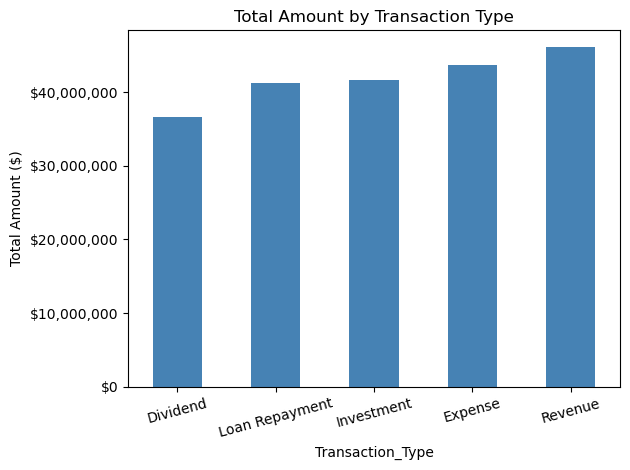

In [5]:
df.groupby('Transaction_Type')['Amount'].sum().sort_values().plot(kind='bar', color='steelblue')
plt.title('Total Amount by Transaction Type')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=15)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

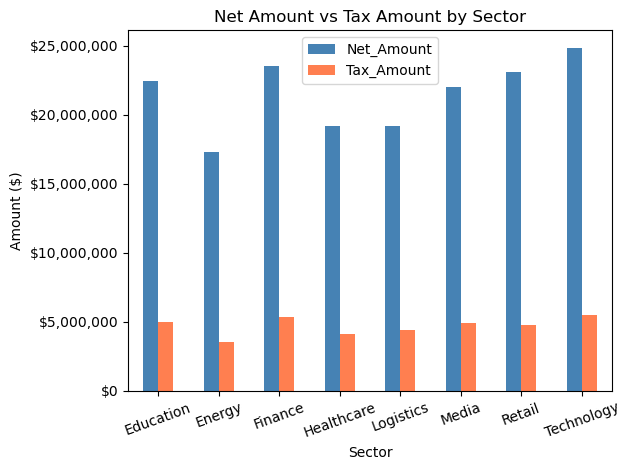

In [6]:
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

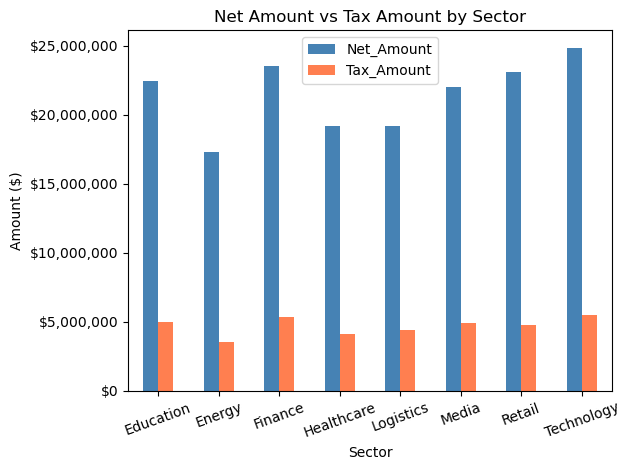

In [7]:
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()